# Aufgaben

In [1]:
# Import
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

## Quiz-Section

## WarmUp
<div>
    <img src=attachment:1d58fba3-dd18-4609-a776-6e3d77859818.png width=100>
</div>
Let's do stretching: Kleinstaufgaben, um die gelernten Funktionen einzuüben.
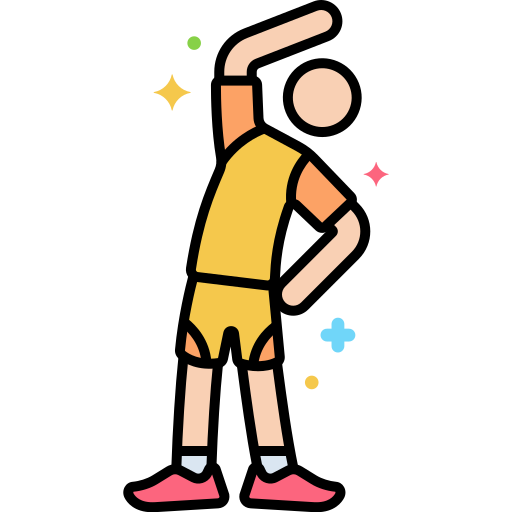

### Aufgabe: G'fühl für'n Train-Test-Split

<div>
    <img src=attachment:dc8d4479-311d-43d0-b923-6768bdcde7e5.png width=200>
</div>

Ihnen liegen die Daten `X` und `y` vor. Schreiben Sie eine Funktion `my_train_test_split`, die Ihnen die Funktion `train_test_split` aus `sklearn` ausführt, die Train-Test-Splits ausgibt und die Trainings- (blau) und Test-Daten (rot) in __einem__ Scatter-Plot visualisiert. Die Eingabeargumente sollen die Daten `X`, `y` und die angestrebte `test_size` sein. Führen Sie die Funktion dann für verschiedene Test-Sizes aus.
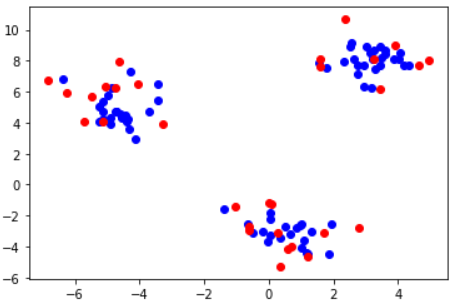

In [2]:
# Your data
X, y = make_blobs()

In [3]:
%%script false --no-raise-error
def my_train_test_split(

Couldn't find program: 'false'


#### Lösung

In [4]:
def my_train_test_split(X, y, test_size=.2):
    """
    
    """
    Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=test_size)
    plt.scatter(Xtrain[:, 0], Xtrain[:, 1], c='blue')
    plt.scatter(Xtest[:, 0], Xtest[:, 1], c='red')
    return Xtrain, Xtest, ytrain, ytest

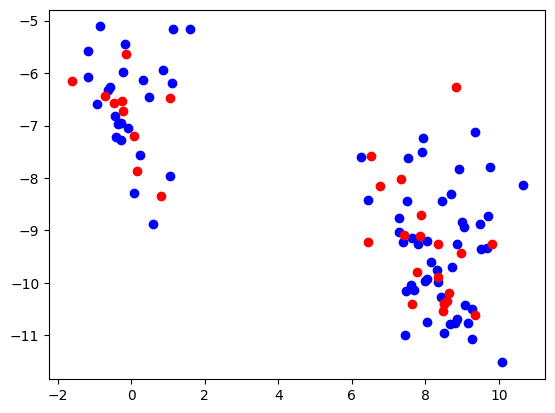

In [5]:
splits = my_train_test_split(X, y, test_size=.3)

In [6]:
splits

(array([[  7.69630198, -10.14119911],
        [  9.7457597 ,  -7.78908165],
        [ 10.64373103,  -8.13320852],
        [ -0.63760593,  -6.32257882],
        [  7.29241601,  -9.02347964],
        [ -0.28241472,  -7.28490328],
        [  0.58822277,  -8.88129506],
        [  8.79731109, -10.76572309],
        [ -0.41387433,  -7.22775119],
        [  1.5985478 ,  -5.16799267],
        [ 10.07436714, -11.51709215],
        [  9.35076205,  -7.1241811 ],
        [ -0.35133884,  -6.96719273],
        [ -0.57420405,  -6.26529162],
        [  8.04478551, -10.74091955],
        [  8.67235142, -10.78362875],
        [  7.90956427,  -7.50191362],
        [  7.28900395,  -8.77206448],
        [  7.48687562, -10.14641723],
        [  8.44525419,  -8.43615143],
        [  7.45536434, -10.99630065],
        [  9.6678581 ,  -9.34062499],
        [  9.26596105, -10.49034133],
        [  8.41590239, -10.26427665],
        [  6.24842541,  -7.5926661 ],
        [  8.84992424, -10.6878217 ],
        [  7

### Aufgabe: "Larifari"-Cross-Validation
Wir nehmen die Cross-Validation Funktionalität unter die Lupe. Wir haben gesehen, dass bei Cross-Validation der Datensatz in _disjunkte Folds_ gesplittet wird. Dies wollen wir jetzt mal nicht so eng sehen und versuchen eine eigene Cross-Validation Funktion `larifari_cross_validation` zu bauen, indem wir die `train_test_split`-Funktion aus `sklearn` verwenden.
* Nutzen Sie einen `for`-Loop, um eine bestimmte Anzahl an Train-Test-Splits durchzuführen - jeder Train-Test-Split soll einem Split des _richtigen_ Cross-Validation-Vorgangs entsprechen
* Auf jeden Split trainieren und testen Sie das Dummy-Modell aus der Vorlesung (`KNeighborsClassifier`) und speichern den _Score_ in eine Liste
* Anschließend mitteln Sie alle _Scores_ und lassen sich diesen Mittelwert als Ausgabeargument zurückgeben: fertig ist die "Larifari"-Cross-Validation
* Vergleichen Sie Ihr Ergebnis mit dem der `cross_val_score`-Funktion

Was unterscheidet unsere Funktion von der _richtigen_ `cross_validation`-Funktion aus `sklearn`?

In [7]:
# Your data
X, y = make_blobs(cluster_std=3)

#### Lösung

In [8]:
def larifari_cross_validation(X, y, num_folds):
    """
    
    """
    list_of_scores = []
    for n_fold in range(num_folds):
        Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=1/num_folds)
        model = KNeighborsClassifier(n_neighbors=1)
        model.fit(Xtrain, ytrain)
        list_of_scores.append(model.score(Xtest, ytest))
    return np.mean(list_of_scores)

In [9]:
larifari_cross_validation(X, y, 5)

np.float64(1.0)

In [10]:
model = KNeighborsClassifier(n_neighbors=1)
array_of_cv_scores = cross_val_score(model, X, y, cv=5)
print(array_of_cv_scores)
print(array_of_cv_scores.mean())

[1. 1. 1. 1. 1.]
1.0


## Python "Schmankerl": Train-Test-Split und Ihre Garage

<div>
    <img src=attachment:ca2ba393-2b85-45ce-a7a1-8692c3f87d21.png width=100>
</div>

Wir wollen die Train-Test-Split-Funktionalität von `sklearn` weiter üben. Sie haben eine große Doppelgarage, die wunderbar aufgeräumt ist. Auf der "linken" Seite stehen Ihre Autos, auf der "rechten" Seite Ihre Radln. Jede Hälfte Ihrer Garage hat genau 10 Stellplätze. Sie würden jetzt gerne umräumen und nutzen hierzu die `train_test_split`-Funktion. Der Train-Split soll der neuen Ordnung der "linken" (`left_garage`), der Test-Split der "rechten" Seite in Ihrer Garage (`right_garage`) entsprechen. Führen Sie `train_test_split` so lange mittels eines `while`-Loops aus, so dass 
* auf der "linken" Seite keine BMWs sind
* auf der "rechten" Seite genau 2 Audis sind
* auf der "linken" Seite von jeder Fahrzeugart (Audi, BMW, VW, BMX, Rennrad) mindestens eins vorhanden ist (hierzu hilft Ihnen die `numpy`-Funktion `np.unique`).

Lassen Sie sich jeweils immer die Garagenseite und die nötigen Iterationen des Loops ausgeben. Hinweis: die `while`-Loops sollen als voneinander unabhängig betrachtet werden.
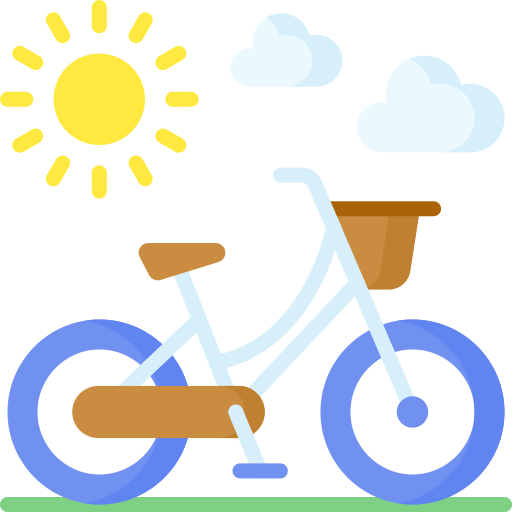

In [11]:
# Your garage
X = np.array(['BMW'] * 5 + ['Audi'] * 3 + ['VW'] * 2 + ['BMX'] * 5 + ['Rennrad'] * 5)
y = np.array(['Auto'] * 10 + ['Radl'] * 10)

# Re-order garage: no BMW on the left

# Re-order garage: 2 Audis on the right

# Re-order garage: at least one of each instance on the left


### Lösung

In [12]:
# Your garage
X = np.array(['BMW'] * 5 + ['Audi'] * 3 + ['VW'] * 2 + ['BMX'] * 5 + ['Rennrad'] * 5)
y = np.array(['Auto'] * 10 + ['Radl'] * 10)

# Re-order garage: no BMW on the left
left_garage = ['BMW']
count_reorders = 0
while 'BMW' in left_garage:
    left_garage, right_garage, ytrain, ytest = train_test_split(X, y, test_size=0.5)
    count_reorders += 1
print(left_garage)
print(count_reorders)

# Re-order garage: 2 Audis on the right
number_of_audis = 0
count_reorders = 0
while number_of_audis != 2:
    left_garage, right_garage, ytrain, ytest = train_test_split(X, y, test_size=0.5)
    number_of_audis = (right_garage == 'Audi').sum()
    count_reorders += 1
print(right_garage)
print(count_reorders)

# Re-order garage: at least one of each instance on the left (np.unique)
unique_items = []
count_reorders = 0
while len(unique_items) != 5:
    left_garage, right_garage, ytrain, ytest = train_test_split(X, y, test_size=0.5)
    unique_items = np.unique(left_garage)
    count_reorders += 1
print(right_garage)
print(count_reorders)

['Rennrad' 'Rennrad' 'Audi' 'Audi' 'BMX' 'BMX' 'Rennrad' 'Rennrad'
 'Rennrad' 'VW']
61
['Rennrad' 'Rennrad' 'BMX' 'BMW' 'BMW' 'BMX' 'BMW' 'Audi' 'VW' 'Audi']
1
['BMW' 'VW' 'BMX' 'BMX' 'BMW' 'Audi' 'Audi' 'Rennrad' 'BMW' 'Rennrad']
3


## Python "Schmankerl": Train-Test-Split from Scratch
Schreiben Sie eine Funktion, die Ihnen einen Train-Test-Split mittels Funktionen aus `numpy` erzeugt. Wie bei der Funktion aus `sklearn` soll Ihre Funktion den Datensatz `X`, die zugehörigen Labels `y` und den Anteil des Trainingsdatensatzes `train_size` als Eingabeargumente aufweisen. Welche `numpy`-Funktionalität könnte Ihnen hierbei helfen, wenn Sie die Wahl der Datenpunkte für den Trainings- bzw. Testdatensatz zufällig treffen wollen? Anmerkung: Sie müssen nicht darauf achten, dass die Klassen gleichmäßig auf die Splits verteilt sind.

In [13]:
# Your data
X, y = make_blobs(n_samples=200)

# Train test split using numpy
def train_test_split_manually(X, y, train_size):
    """
    
    """
    # Concatenate
    
    # Shuffle
    
    # Split
    

### Lösung

In [14]:
# Your data
X, y = make_blobs(n_samples=200)

# Train test split using numpy
def train_test_split_manually(X, y, train_size):
    """
    
    """
    # Concatenate
    X_y = np.concatenate((X, y.reshape(-1, 1)), axis=1)
    
    # Shuffle
    np.random.shuffle(X_y)
    
    # Split
    X_y_train = X_y[:int(train_size * X.shape[0]), :]
    X_y_test = X_y[int(train_size * X.shape[0]):, :]
    
    return X_y_train[:, :-1], X_y_train[:, -1], X_y_test[:, :-1], X_y_test[:, -1]

In [15]:
X_train, X_test, y_train, y_test = train_test_split_manually(X, y, 0.75)

## Python "Schmankerl": Polynomfunktionsspaß
Wir haben gesehen, dass eine Polynomfunktion folgendermaßen ausgedrückt wird

$$f(x) = a_n x^n + \dots + a_1 x + a_0.$$

Schreiben Sie eine Funktion, die Ihnen mittels eines `for`-Loops eine Polynomfunktion erzeugt, berechnet und als Ausgabeargument den errechneten Wert $f(x)$ zurückgibt. Welche Eingabeargumente benötigt die Funktion?
Versuchen Sie die Polynomfunktion auf verschiedene Weisen zu programmieren:
* Plain Python: nur Python Code verwenden - ohne Zusatz-Packages
* Mit `numpy`: googlen Sie, wie man mit `numpy` eine Polynomfunktion ausdrückt
* Mittels der sog. _Horner's Method_ - googlen Sie danach.

### Lösung

In [16]:
# Plain python
def eval_polynomial(coeff_array, x):
    return sum((coeff * x ** degree for degree, coeff in enumerate(coeff_array)))

In [17]:
# NumPy
p1 = np.poly1d([3, 2, 1])

In [18]:
# Horner's method
def eval_polynomial(coeff_array, x):
    '''

    '''
    result = 0
    for coeff in coeff_array:
        result = x * result + coeff
    return result

## Python "Schmankerl": Data-Generator

<div>
    <img src=attachment:c01fd261-8087-4071-8c8f-287c99a38821.png width=200>
</div>

Bauen Sie eine Funktion, die Ihnen Daten generiert, die einer Polynomfunktion folgen. Generieren Sie Datensätze für Polynome verschiedener Ordnungen. Bauen Sie eine Möglichkeit ein, dass auf die generierten Daten Rauschen addiert wird. Der Wertebereich der generierten Daten soll zwischen $-5$ und $5$ liegen. Die Anzahl der generierten Datenpunkte und das Ausmaß des Rauschens sollen mittels Eingabeargumenten einstellbar sein. Plotten Sie Ihre Daten als Scatter-Plot.
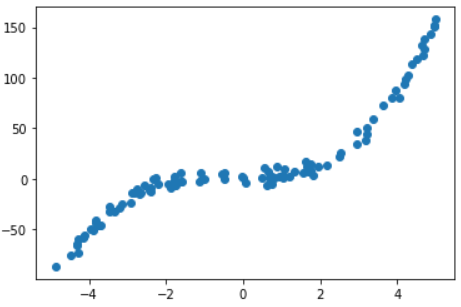

### Lösung

In [19]:
# Generate some polynomial data
def make_polynomial_data(N=100, noise=0.08, coeff_array=[1, 1, 1]):
    X = (2 * np.random.rand(N, 1) - 1) * 5
    y = np.array([eval_polynomial(coeff_array, x) for x in X])
    if noise > 0:
        y += noise * np.random.randn(N, 1)
    return X, y

In [20]:
# Execute
X, y = make_polynomial_data(coeff_array=[1, 1, 1, 1], noise=5)

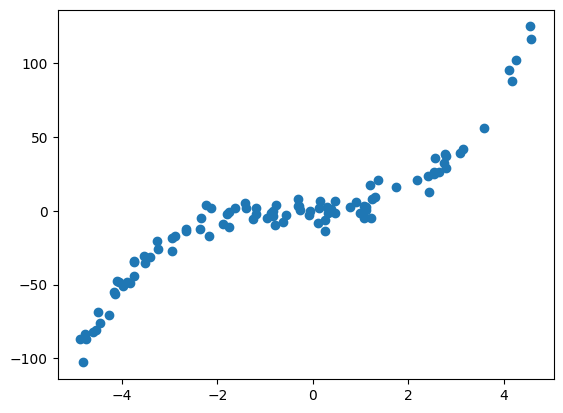

In [21]:
# Plot
plt.scatter(X, y);

## Grid Search from Scratch

<div>
    <img src=attachment:38f33693-bd49-4d6f-aec8-7025f8efafa3.png width=100>
</div>

Schreiben Sie eine Funktion, die Ihnen einen Grid Search durchführt, ohne auf die Klasse `GridSearchCV` zurückzugreifen. Nutzen Sie hierfür die `PolynomialRegression` aus unserem Vorlesungsbeispiel als Modell. Schauen Sie in die Dokumentation der Klasse `LinearRegression`: welche weiteren Hyperparameter stehen für unseren Grid-Search zur Auswahl? Erzeugen Sie sich zwei Funktionen:

* `larifari_grid_search`: diese Funktion soll den Grid-Search "mehr oder weniger" ausführen. Diese Funktion soll den Grid-Search ausführen - jedoch die Suche abbrechen, wenn der Wert des _Scores_ einen gewünschten Wert überschreitet. Das Ausgabeargument soll dann das, zu diesem Score gehörige, Modell sein. Bei dieser Funktion müssen Sie keine Cross-Validation durchführen. Auch der Hyperparameterraum muss nicht vollständig "abgefahren" werden.

* `full_grid_search_from_scratch`: diese Funktion soll den vollständigen Grid-Search, wie wir ihn in der Vorlesung kennengelernt hatten und wie ihn die `GridSearchCV`-Klasse durchführt, abbilden. D.h. Sie müssen hier darauf achten, dass der gesamte Hyperparameterraum "abgefahren" wird. Dann soll aus den berechneten Cross-Validation-Scores das Optimum gewählt werden und das zugehörige Modell als Ausgabeargument zurückgegeben werden. Bei dieser Funktion benötigen Sie keinen Schwellwert mehr für den Score.
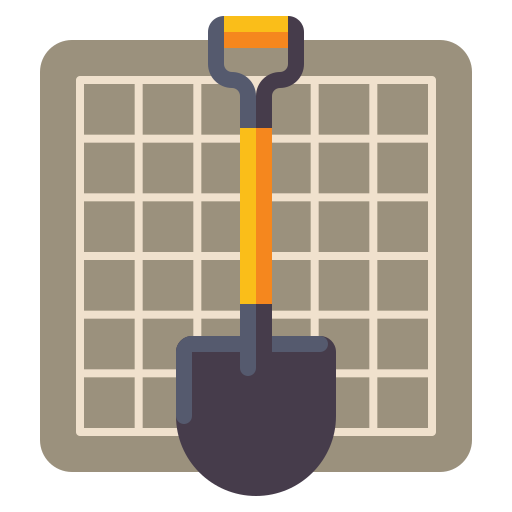

### Lösung

In [22]:
def PolynomialRegression(degree=2, fit_intercept=True):
    return make_pipeline(PolynomialFeatures(degree),
                         LinearRegression(fit_intercept=fit_intercept))

In [23]:
# Larifari grid search from scratch with PolynomialRegression class
def larifari_grid_search(X, y, degree_range, threshold_criterion):
    """
    
    """

    Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3)
    for degree in degree_range:
        for intercept in [True, False]:
            model = PolynomialRegression(degree=degree, fit_intercept=intercept).fit(Xtrain, ytrain)
            criterion_score = model.score(Xtest, ytest)
            if criterion_score >= threshold_criterion:
                return model

In [24]:
# Full grid search from scratch
def full_grid_search_from_scratch(Xtrain, ytrain, degree_range):
    """
    
    """

    array_of_scores = np.zeros((len(degree_range), 2))
    array_of_params = np.zeros((len(degree_range), 2, 2)) # Using two arrays covers a more general case: imagine having hyperparameter values, which cannot be represented by indices of arrays
    for index_degree, degree in enumerate(degree_range):
        for index_intercept, intercept in enumerate([True, False]):
            model = PolynomialRegression(degree=degree, fit_intercept=intercept)
            array_of_scores[index_degree, index_intercept] = np.mean(cross_val_score(model, Xtrain, ytrain, cv=5))
            array_of_params[index_degree, index_intercept] = np.array([degree, intercept])
    
    # Get best hyperparameters
    coordinates_max = np.unravel_index(np.argmax(array_of_scores), array_of_scores.shape)

    # Train final model
    model = PolynomialRegression(degree=int(array_of_params[coordinates_max][0]),
                                 fit_intercept=bool(array_of_params[coordinates_max][1]),
                                 ).fit(Xtrain, ytrain)
    return model

In [25]:
# Data
def make_data(N=300, err=0.8, rseed=1):
    
    # randomly sample the data
    rng = np.random.RandomState(rseed)
    X = rng.rand(N, 1) ** 2
    y = 10 - 1. / (X.ravel() + 0.1)
    if err > 0:
        y += err * rng.randn(N)
    return X, y

X, y = make_data(N=200)

In [26]:
larifari_grid_search(X, y, range(10), 0.1)

,steps,"[('polynomialfeatures', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,1
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


In [27]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3)
full_grid_search_from_scratch(Xtrain, ytrain, range(10))

,steps,"[('polynomialfeatures', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,9
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


# Quellen

<div>
    <img src=attachment:7ae665a2-756c-492a-8763-45e2fdb03909.png width=100>
</div>
<div>Icons made by <a href="https://www.freepik.com" title="Freepik">Freepik</a> from <a href="https://www.flaticon.com/" title="Flaticon">www.flaticon.com</a></div>

<div>
    <img src=attachment:57180642-bb07-44ca-8f93-f8b89f6a75db.png width=100>
</div>
<div>Icons made by <a href="https://www.flaticon.com/authors/flat-icons" title="Flat Icons">Flat Icons</a> from <a href="https://www.flaticon.com/" title="Flaticon">www.flaticon.com</a></div>

<div>
    <img src=attachment:572e3a41-2644-4d2e-8256-03099318d268.png width=100>
</div>
<div>Icons made by <a href="https://www.flaticon.com/authors/flat-icons" title="Flat Icons">Flat Icons</a> from <a href="https://www.flaticon.com/" title="Flaticon">www.flaticon.com</a></div>
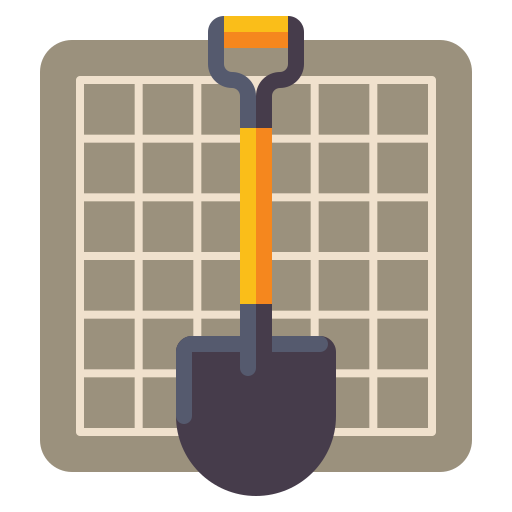
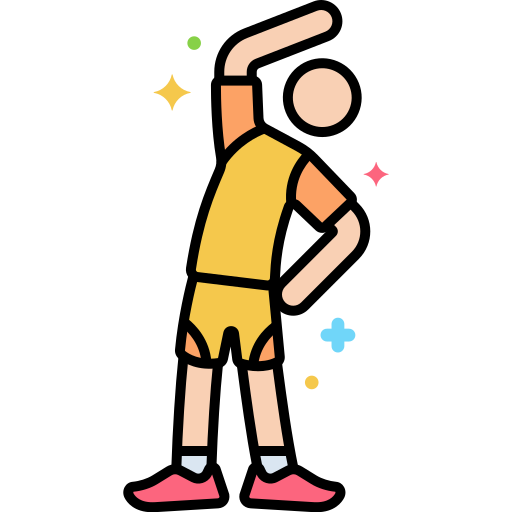
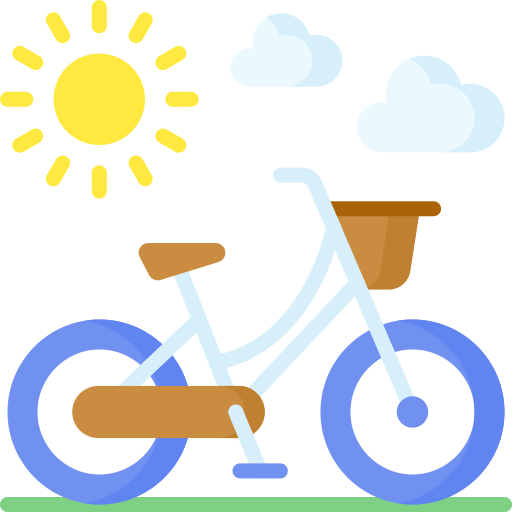